
This data set consists of two files: a CSV containing the training data, including the target values, and a CSV containing the test data which does not contain the target.
We are interested to train a model capable of stating whether an unknown individual was likely to survive or not at the titanic disaster.
We start out by loading the two training sets and plotting the first 5 rows of the training set.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import Imputer
from sklearn.preprocessing import MinMaxScaler

train = pd.read_csv("../input/train.csv")
test = pd.read_csv("../input/test.csv")
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Name           418 non-null object
Sex            418 non-null object
Age            332 non-null float64
SibSp          418 non-null int64
Parch          418 non-null int64
Ticket         418 non-null object
Fare           417 non-null float64
Cabin          91 non-null object
Embarked       418 non-null object
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [2]:

train.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


First of all it is quite clear wi will drop the name as irrelevant. However there is an interesting information we can easily extract from the name: the Title (i.e. Capt., Col., Major., etc.) which may correlate with our target.

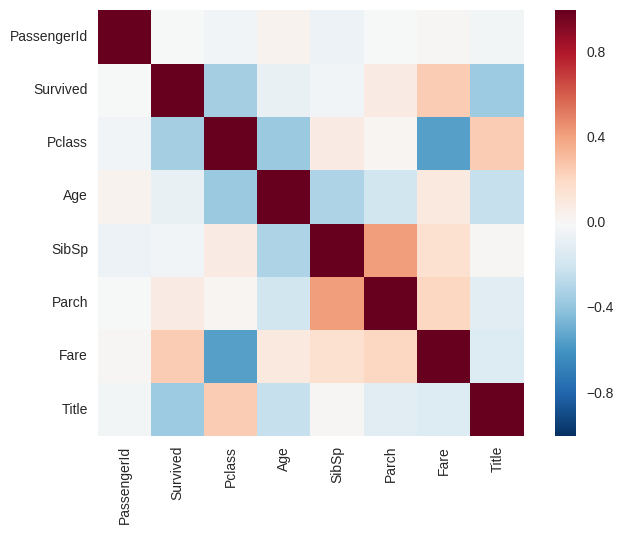

In [3]:
train['Title'] = train['Name'].map(lambda name:name.split(',')[1].split('.')[0].strip())
Title_Dictionary = {
                        "Capt":       0,
                        "Col":        0,
                        "Major":      0,
                        "Jonkheer":   1,
                        "Don":        1,
                        "Sir" :       1,
                        "Dr":         0,
                        "Rev":        0,
                        "the Countess":1,
                        "Dona":       1,
                        "Mme":        2,
                        "Mlle":       3,
                        "Ms":         2,
                        "Mr" :        4,
                        "Mrs" :       2,
                        "Miss" :      3,
                        "Master" :    5,
                        "Lady" :      1

                        }
    
train['Title'] = train.Title.map(Title_Dictionary)
f,ax1 = plt.subplots()
corr = train.corr()
sns.heatmap(corr, vmax=1, square=True,ax=ax1)
plt.show()

It seems the Survived feature is mainly related to Age, Pclass, Parch and Fare. We may try dropping Name, Ticket, Cabin and PassengerId and SibSp.

In [4]:
fdf = train.drop(['PassengerId','Name','Ticket','Cabin','SibSp'],1)
fdf.head()

,Survived,Pclass,Sex,Age,Parch,Fare,Embarked,Title
0,0,3,male,22.0,0,7.2500,S,4
1,1,1,female,38.0,0,71.2833,C,2
2,1,3,female,26.0,0,7.9250,S,3
3,1,1,female,35.0,0,53.1000,S,2
4,0,3,male,35.0,0,8.0500,S,4


We can now try to train some supervised models in order to choose the one which better fits with our data. To this end we create a vector with the target information we want to know: the survived vector. Then we drop that column from the original data frame and we get the data frame of features we need to train the model. We turn the Gender and Embarked information from strings to integers.

In [5]:
survived = fdf['Survived']
features = fdf.drop(['Survived'],axis=1)
features['Sex'] = features['Sex'].map( {'female': 1, 'male': 0} ).astype(int)
features['Embarked'] = features['Embarked'].map( {'S': 0, 'C': 1, 'Q':2},na_action=None )

Now we have to deal with not assigned values which are present in Age, Fare and Embarked features. I first tried with an Inputer but I realized there can be a correlation among these data and Gender/PClass/Title. So we can create groups and use the mean values for each group to replace NaN values.

In [6]:
grouped = features.groupby(['Sex','Pclass','Title'])
gm = grouped.median()
print(gm)

                   Age  Parch       Fare  Embarked
Sex Pclass Title                                  
0   1      0      51.0      0   35.50000       0.0
           1      40.0      0   27.72080       1.0
           4      40.0      0   42.40000       0.0
           5       4.0      2  120.00000       0.0
    2      0      46.5      0   13.00000       0.0
           4      31.0      0   13.00000       0.0
           5       1.0      1   26.00000       0.0
    3      4      26.0      0    7.89580       0.0
           5       4.0      1   28.51250       0.0
1   1      0      49.0      0   25.92920       0.0
           1      40.5      0   63.05000       0.5
           2      40.0      0   79.20000       0.0
           3      30.0      0   88.25000       1.0
    2      2      31.5      0   26.00000       0.0
           3      24.0      0   13.00000       0.0
    3      2      31.0      1   15.97500       0.0
           3      18.0      0    8.75625       0.0


In [7]:
gm['Age'][0]

features.Age = features.apply(lambda item : gm['Age'][item['Sex'],item['Pclass'],item['Title']] if np.isnan(item['Age']) else item['Age'], axis=1)
features.Age = features['Age'].apply(lambda x: np.log(x + 1))

/opt/conda/lib/python3.5/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


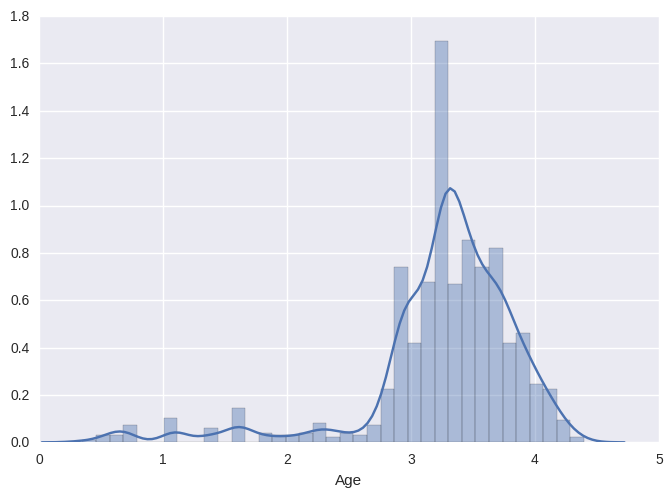

In [8]:
sns.distplot(features['Age'])
plt.show()

/opt/conda/lib/python3.5/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


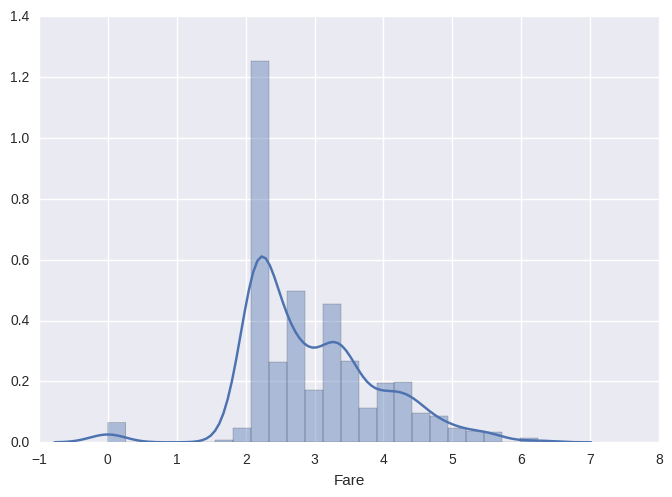

In [9]:
features.Fare = features.apply(lambda item : gm['Fare'][item['Sex'],item['Pclass'],item['Title']] if np.isnan(item['Fare']) else item['Fare'], axis=1)
features.Fare = features['Fare'].apply(lambda x: np.log(x + 1))

sns.distplot(features['Fare'])
plt.show()

/opt/conda/lib/python3.5/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


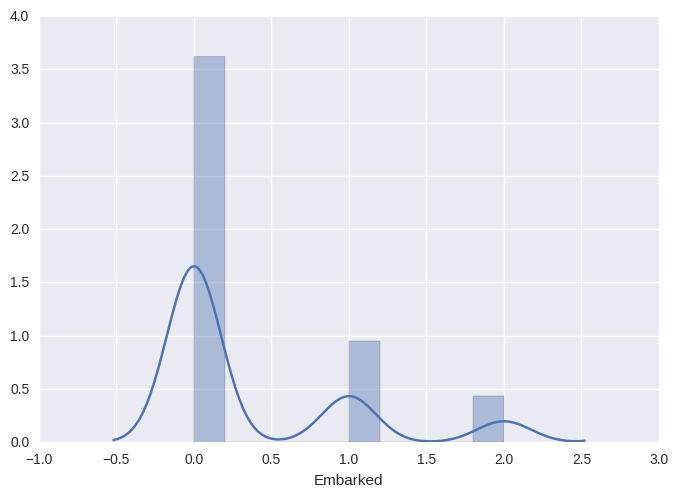

In [10]:
from math import ceil
features.Embarked = features.apply(lambda item : ceil(gm['Embarked'][item['Sex'],item['Pclass'],item['Title']]) if np.isnan(item['Embarked']) else item['Embarked'], axis=1)
#features.Embarked = features['Embarked'].apply(lambda x: np.log(x + 1))

sns.distplot(features['Embarked'])
plt.show()

In [11]:
pclass_dummies = pd.get_dummies(features['Pclass'],prefix="Pclass")
embarked_dummies =  pd.get_dummies(features['Embarked'],prefix="Embarked")
 # adding dummy variables
features.drop('Pclass',axis=1,inplace=True)
features.drop('Embarked',axis=1,inplace=True)
features = pd.concat([features,pclass_dummies],axis=1)
features = pd.concat([features,embarked_dummies],axis=1)

Now we use the train_test_split function to randomly choose 20% of individuals for test and 80% of individuals for training

In [12]:
from sklearn import tree
from sklearn.cross_validation import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
from sklearn.svm import SVC
import random 
from sklearn.ensemble import RandomForestClassifier
from sklearn import neighbors
from time import time
from sklearn.metrics import accuracy_score
from sklearn.metrics import fbeta_score

X_train, X_test, y_train, y_test = train_test_split(features, survived, test_size = 0.2, random_state = 0)
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

def train_predict(learner, X_train, y_train, X_test, y_test): 
    
    results = {}
    start = time() # Get start time
    learner.fit(X_train,y_train)
    end = time() # Get end time
    results['train_time'] = end-start
        
    start = time() # Get start time
    predictions_test = learner.predict(X_test)
    predictions_train = learner.predict(X_train)
    end = time() # Get end time
    
    results['pred_time'] = end-start
    results['acc_train'] = accuracy_score(y_train,predictions_train)
    results['acc_test'] = accuracy_score(y_test,predictions_test)
    results['f_train'] = fbeta_score(y_train,predictions_train,beta=0.5)
    results['f_test'] = fbeta_score(y_test,predictions_test,beta=0.5)
    
    return results

Training set has 712 samples.
Testing set has 179 samples.


/opt/conda/lib/python3.5/site-packages/sklearn/cross_validation.py:44: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. Also note that the interface of the new CV iterators are different from that of this module. This module will be removed in 0.20.
  "This module will be removed in 0.20.", DeprecationWarning)


Then we compare three possible models:
Gaussian Naive Bayes
Decision Tree
Random Forest

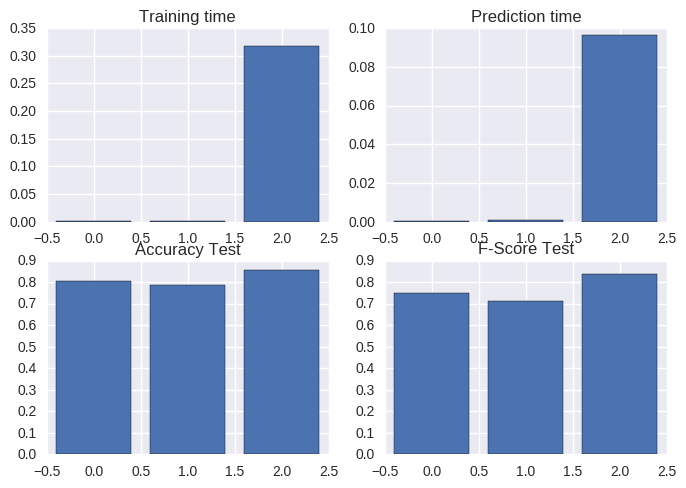

In [13]:

clf_A = GaussianNB()
clf_B = tree.DecisionTreeClassifier()
clf_C = RandomForestClassifier(n_estimators=200,criterion='gini')

results = {}
for clf in [clf_A, clf_B, clf_C]:
    clf_name = clf.__class__.__name__
    results[clf_name] = {}
    results[clf_name] =  train_predict(clf, X_train, y_train, X_test, y_test)

train_time = {}
pred_time = {}
acc_train = {}
acc_test = {}
f_train = {}
f_test ={}

for k in results.keys():
    train_time[k] = results[k]["train_time"]
    pred_time[k] = results[k]["pred_time"]
    acc_train[k]  = results[k]["acc_train"]
    acc_test[k]   = results[k]["acc_test"]
    f_train[k]    = results[k]["f_train"]
    f_test[k]     = results[k]["f_test"]
    
    

f,axarray = plt.subplots(2,2)
axarray[0,0].set_title("Training time")
axarray[0,0].bar(range(len(train_time)), train_time.values(), align='center')
axarray[0,0].set_xticks(range(len(train_time)), train_time.keys())

axarray[0,1].set_title("Prediction time")
axarray[0,1].bar(range(len(pred_time)), pred_time.values(), align='center')
axarray[0,1].set_xticks(range(len(pred_time)), pred_time.keys())

axarray[1,0].set_title("Accuracy Test")
axarray[1,0].bar(range(len(acc_test)), acc_test.values(), align='center')
axarray[1,0].set_xticks(range(len(acc_test)), acc_test.keys())

axarray[1,1].set_title("F-Score Test")
axarray[1,1].bar(range(len(f_test)), f_test.values(), align='center')
axarray[1,1].set_xticks(range(len(f_test)), f_test.keys())
plt.show()


Although Random Forest takes far more time than the other two models it performs better.

In [14]:
#clf_C.fit(features,survived)


imp = Imputer(missing_values='NaN', strategy='most_frequent', axis=0)
test['Title'] = test['Name'].map(lambda name:name.split(',')[1].split('.')[0].strip())
test['Title'] = test.Title.map(Title_Dictionary)

test_input = test.drop(['PassengerId','Name','Ticket','Cabin','SibSp'],1)

test_input['Sex'] = test_input['Sex'].map( {'female': 1, 'male': 0} ).astype(int)
test_input['Embarked'] = test_input['Embarked'].map( {'S': 0, 'C': 1, 'Q':2},na_action=None )
test_input['Embarked'] =  imp.fit_transform(test_input['Embarked'].values.reshape(-1,1))

test_input.Embarked = test_input.apply(lambda item : ceil(gm['Embarked'][item['Sex'],item['Pclass'],item['Title']]).astype(int) if np.isnan(item['Embarked'].astype(int)) else item['Embarked'], axis=1)

test_input.Age = test_input.apply(lambda item : gm['Age'][item['Sex'],item['Pclass'],item['Title']] if np.isnan(item['Age']) else item['Age'], axis=1)
test_input.Age = test_input['Age'].apply(lambda x: np.log(x + 1))

test_input.Fare = test_input.apply(lambda item : gm['Fare'][item['Sex'],item['Pclass'],item['Title']] if np.isnan(item['Fare']) else item['Fare'], axis=1)
test_input.Fare = test_input['Fare'].apply(lambda x: np.log(x + 1))

pclass_dummies = pd.get_dummies(test_input['Pclass'],prefix="Pclass")
embarked_dummies =  pd.get_dummies(test_input['Embarked'],prefix="Embarked")
 # adding dummy variables
test_input.drop('Pclass',axis=1,inplace=True)
test_input.drop('Embarked',axis=1,inplace=True)
test_input = pd.concat([test_input,pclass_dummies],axis=1)
test_input = pd.concat([test_input,embarked_dummies],axis=1)

pd.isnull(test_input).any()

#test_input['Fare'] = test_input['Fare'].apply(lambda x: np.log(x + 1))
#test_input['Fare'] =  imp.fit_transform(test_input['Fare'].values.reshape(-1,1))



#test_input.head()

Sex             False
Age             False
Parch           False
Fare            False
Title           False
Pclass_1        False
Pclass_2        False
Pclass_3        False
Embarked_0.0    False
Embarked_1.0    False
Embarked_2.0    False
dtype: bool

In [15]:
print ("using {}".format(clf_C.__class__.__name__))
prediction = clf_C.predict(test_input)
predition =  prediction.astype(int)
submission = pd.DataFrame({
        "PassengerId": test["PassengerId"],
        "Survived": prediction.astype(int)
    })
submission.to_csv('titanic.csv', index=False)

using RandomForestClassifier
